# Examen: Análisis de Datos Avanzado y Optimización en Decisiones Empresariales

## Empresa: AnalyticsPro Solutions

### Introducción

AnalyticsPro Solutions es una empresa que proporciona servicios de análisis avanzados y optimización de estrategias para empresas SaaS (Software como Servicio). Su enfoque principal es mejorar la eficiencia en los procesos de negocio mediante el uso de análisis predictivo, análisis inferencial, y optimización de decisiones empresariales.

### Contexto General

AnalyticsPro Solutions tiene cuatro áreas clave de enfoque:

1. **Pronóstico de Nuevos Usuarios**: Ayudar a las empresas a prever cuántos usuarios nuevos obtendrán cada mes.
2. **Optimización de Experiencia del Cliente**: Analizar las métricas que afectan la retención de clientes y proponer estrategias para mejorar la fidelidad.
3. **Definición de precios**: Hace soporte en la selección de precios que apoye el alcance de objetivos.
4. **Estrategias de Adquisición de Usuarios**: Determinar la asignación óptima de presupuesto en diferentes canales de marketing digital.

---

## Instrucciones Generales

- Este examen se centra en aplicar técnicas avanzadas de análisis de datos y optimización en un contexto práctico.
- Utiliza Python y, cuando sea necesario, herramientas como `auto-ts`, `scipy.optimize`, `semopy` y `statsmodels`.
- Proporciona tus razonamientos, interpretaciones y pasos detallados para cada pregunta.

---

## Parte 1: Pronóstico de Nuevos Usuarios con `auto-ts` (25 puntos)

**Contexto**  
AnalyticsPro Solutions desea prever cuántos usuarios nuevos obtendrá su cliente, Chaquetas Pal Frio, SA de CV, una marca de chaquetas para climas frios, en los próximos 12 meses, basándose en los datos de los últimos tres años. Este análisis es crucial para ajustar las estrategias de adquisición y recursos disponibles.

**Ejercicio**  
1. **Construcción del Modelo (15 puntos):**  
   - Utiliza `auto-ts` (o Prophet y ARIMA como alternativa) para construir un modelo de pronóstico que estime los nuevos usuarios mensuales para el próximo año.
   - Realiza una división del conjunto de datos en entrenamiento (70%) y prueba (30%).
   - Genera un gráfico que muestre los datos históricos, las predicciones del modelo en el conjunto de prueba, y las predicciones para los próximos 12 meses.
   - Calcula el RMSE en el conjunto de prueba y muestra un gráfico que visualice las predicciones futuras.

2. **Recomendación de Estrategias (10 puntos):**  
   - Basándote en los resultados del modelo, recomienda dos estrategias específicas para gestionar los recursos necesarios para captar nuevos usuarios en función de los picos y tendencias observadas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error
from prophet import Prophet
import pmdarima as pm

In [2]:
df = pd.read_csv('data/new_users_forecast.csv', parse_dates=['month'])
df = df.rename(columns={"month": "ds", "new_users": "y"})
df.head()

,ds,y
0,2021-01-31,1225.0
1,2021-02-28,1235.0
2,2021-03-31,1110.0
3,2021-04-30,1178.0
4,2021-05-31,1100.0


## Prophet

In [3]:
train_size = int(0.8 * len(df))
train_df = df[:train_size]
test_df = df[train_size:]

In [4]:
m = Prophet()
m.fit(train_df)
forecast = m.predict(test_df[['ds']])

14:49:53 - cmdstanpy - INFO - Chain [1] start processing
14:49:53 - cmdstanpy - INFO - Chain [1] done processing


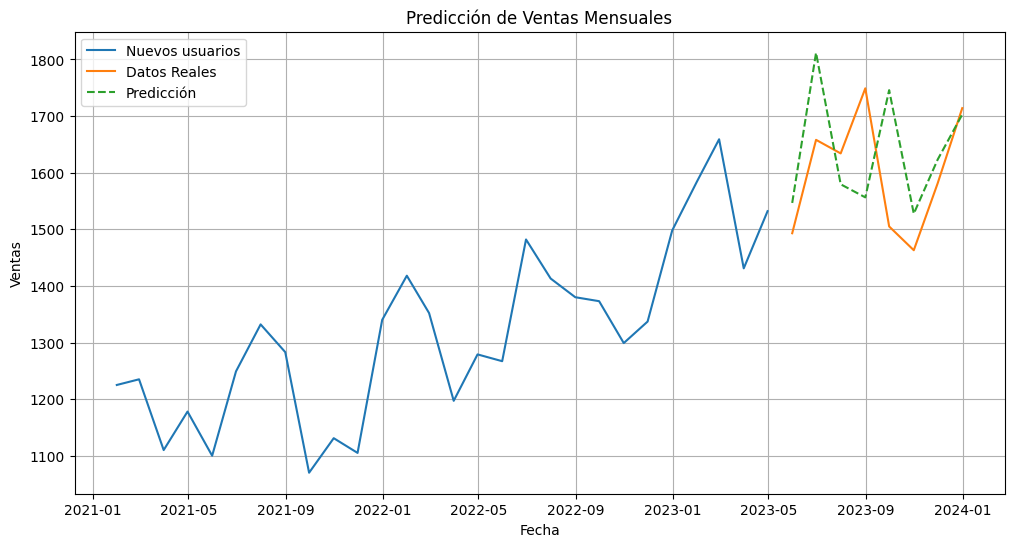

In [5]:
plt.figure(figsize=(12,6))
plt.plot(train_df['ds'], train_df['y'], label='Nuevos usuarios')
plt.plot(test_df['ds'], test_df['y'], label='Datos Reales')
plt.plot(test_df['ds'], forecast['yhat'], label='Predicción', linestyle='--')
plt.title('Predicción de Ventas Mensuales')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
rmse_prophet = root_mean_squared_error(test_df['y'], forecast['yhat'])
print(f"RMSE Prophet: {rmse_prophet}")

RMSE Prophet: 127.79953001432402


## ARIMA

In [7]:
train_size = int(0.9 * len(df))
train_df = df[:train_size]
test_df = df[train_size:]

arima_model = pm.auto_arima(
    train_df['y'],
    seasonal=True,
    m=12,
    stepwise=True,
    suppress_warnings=True
)

n_periods = len(test_df['y'])
forecast = arima_model.predict(n_periods=n_periods)

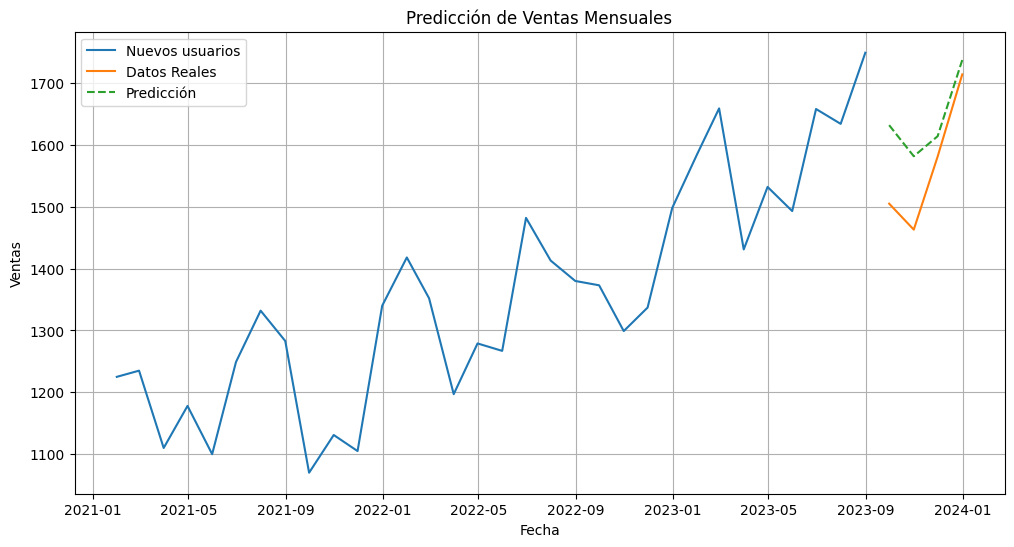

In [8]:
plt.figure(figsize=(12,6))
plt.plot(train_df['ds'], train_df['y'], label='Nuevos usuarios')
plt.plot(test_df['ds'], test_df['y'], label='Datos Reales')
plt.plot(test_df['ds'], forecast, label='Predicción', linestyle='--')
plt.title('Predicción de Ventas Mensuales')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
rmse_arima = root_mean_squared_error(test_df['y'], forecast)
print(f"RMSE ARIMA: {rmse_arima}")

RMSE ARIMA: 89.15516979248794


## Pronóstico siguientes 12 meses

ARIMA fue el que mejor RMSE tuvo

In [10]:
arima_model = pm.auto_arima(
    df['y'],
    seasonal=True,
    m=12,
    stepwise=True,
    suppress_warnings=True
)

forecast = arima_model.predict(n_periods=12)

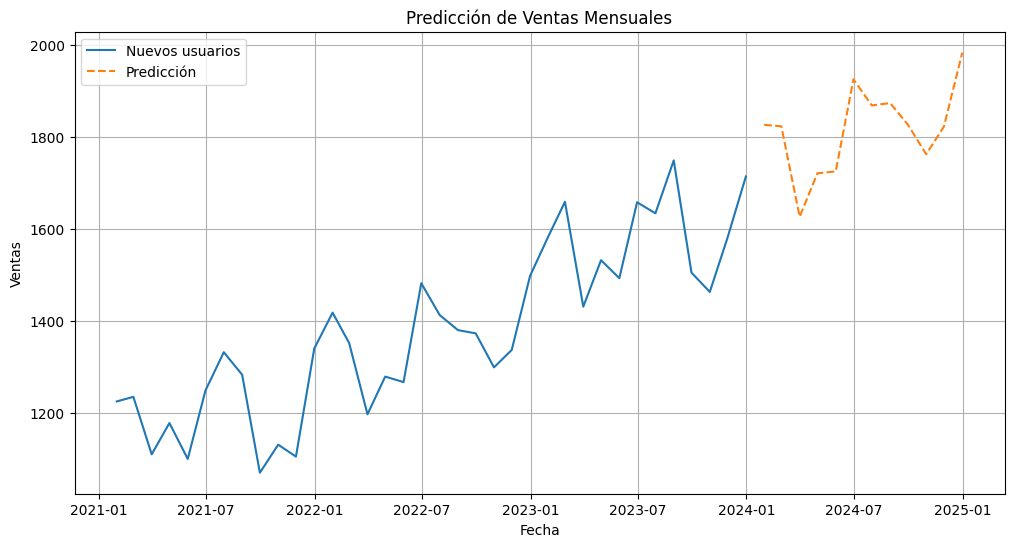

In [11]:
future_dates = pd.date_range(start=df['ds'].max() + pd.DateOffset(months=1), periods=12, freq='M')

plt.figure(figsize=(12,6))
plt.plot(df['ds'], df['y'], label='Nuevos usuarios')
plt.plot(future_dates, forecast, label='Predicción', linestyle='--')
plt.title('Predicción de Ventas Mensuales')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

Conclusión: Se observa estacionalidad en los meses de julio, agosto, diciembre, enero y febrero. Estos meses son considerados frios o meses de lluvia en algunos estados del país.
1. Aprovecharía esta tendencia para lanzar campañas promoviendo la proteción del frio o lluvias con el producto.
2. Los meses restantes pensaría en algún tipo de oferta con los productos que no se vendieron de la temporada

---

## Parte 2: Optimización de Experiencia del Cliente con SEM (15 puntos)

**Contexto**  
AnalyticsPro Solutions busca analizar cómo las métricas de experiencia del cliente afectan la retención de uno de sus principales clientes. Se han identificado las siguientes variables clave:
- **Engagement en la Plataforma**: Un índice calculado con base en el tiempo promedio de uso semanal, el número de interacciones, y las sesiones activas por usuario.
- **Soporte al Cliente**: Medido por los tiempos de respuesta y el índice de resolución de problemas.
- **Retención del Cliente**: Una variable clave para determinar el éxito de las estrategias de fidelización.

**Ejercicio**  
1. **Construcción del Modelo SEM (10 puntos):**  
   - Crea un modelo SEM que incluya las variables latentes **Engagement en la Plataforma** (medido por `Tiempo Promedio`, `Interacciones`, y `Sesiones Activas`) y **Soporte al Cliente** (medido por `Tiempo de Respuesta` y `Resolución de Problemas`).
   - Genera un gráfico de las trayectorias y muestra las cargas factoriales y coeficientes.

2. **Interpretación y Recomendaciones (5 puntos):**  
   - Propón dos acciones específicas para mejorar las métricas de engagement y soporte.


In [12]:
from semopy import Model, Optimizer, semplot
from sklearn.preprocessing import StandardScaler

In [13]:
df = pd.read_csv('data/retention_data.csv')
df.head()

,tiempo_promedio,interacciones,sesiones_activas,tiempo_respuesta,resolucion_problemas,retencion
0,21.044318,8,16.715266,1.724732,0.333628,9.587410
1,10.201649,8,17.772422,1.389644,0.791558,7.112177
2,13.359070,7,15.705766,1.745930,0.451294,6.206844
3,20.984306,13,13.531889,1.926110,0.183442,8.983417
4,23.692333,10,11.689639,1.773376,0.854974,9.345260


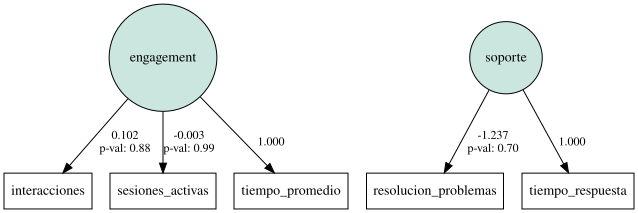

In [14]:
scaler = StandardScaler()
df_stand = scaler.fit_transform(df)

model_desc = """
# Latent Variables
engagement =~ tiempo_promedio + interacciones + sesiones_activas
soporte =~ tiempo_respuesta + resolucion_problemas
"""

mod = Model(model_desc)
res_opt = mod.fit(df)
estimates = mod.inspect()

semplot(mod, "data/pd.png")

Conclusión:
1. Dados los p-values esperaria que la empresa busque tener mas información que de pie a medir el soporte a cliente o el engagement. No es un resultado que pueda corelacionarse mucho con las variables latentes usando el modelo especifico.
1. Asuimiendo que los p-values no fuesen mayores a 0.05, para soporte al cliente buscaría tener definida una meta de tiempo de respuesta que cumpla con las expectativas de cliente.

---

## Parte 3: Evaluación de Precios con Pruebas A/B (30 puntos)

### Contexto

Correcaminos, SA de CV, una empresa de entrega a domicilio, contrató a AnalyticsPro Solutions para ajustar su esquema de precios. El principal objetivo de Correcaminos es aumentar el **Ingreso Promedio por Usuario (ARPU)** en al menos **300 MXN**. Actualmente, el modelo de precios cobra **60 MXN** por cada kilómetro de trayecto. Sin embargo, un análisis previo sugiere que el precio debería incrementarse a **78 MXN** por kilómetro. Adicionalmente, el dueño teme que este aumento pueda provocar una disminución significativa en la tasa de conversión.

---

### Ejercicio

#### Parte 1: Diseño de la Prueba A/B (10 puntos)

1. Define dos pruebas A/B para evaluar los objetivos de Correcaminos:
   - **Prueba 1 (ARPU):** El **Grupo A** utiliza el precio actual (**60 MXN**), mientras que el **Grupo B** utiliza el precio actualizado (**78 MXN**). Esta prueba busca determinar si el ARPU aumenta en al menos **300 MXN**.
   - **Prueba 2 (Tasa de Conversión):** El **Grupo A** utiliza el precio actual (**60 MXN**), mientras que el **Grupo B** utiliza el precio actualizado (**78 MXN**). Esta prueba busca determinar si la tasa de conversión no disminuye significativamente.

2. Usando los datos de `correcaminos_historical_arpu.csv`, calcula el tamaño mínimo de muestra necesario para detectar un aumento de **300 MXN** en el ARPU con un nivel de confianza del **95%** y un poder estadístico del **80%**.

3. Usando los datos de `correcaminos_historical_conversion.csv`, calcula el tamaño mínimo de muestra necesario para detectar una disminución significativa en la tasa de conversión con el mismo nivel de confianza y poder estadístico.

---

#### Parte 2: Análisis de Resultados de la Prueba (20 puntos)

Después de dos semanas, la empresa comparte los resultados en los archivos `correcaminos_resultado_arpu_ab_test.csv` y `correcaminos_resultado_conversion_ab_test.csv`. Realiza lo siguiente:

1. Evalúa si se cumplieron los objetivos de la empresa mediante pruebas de hipótesis:
   - **Para el ARPU:** Realiza una prueba t de dos muestras para comparar si el ARPU del **Grupo B** es significativamente mayor que el del **Grupo A** y cumple con el incremento de **300 MXN**.
   - **Para la Tasa de Conversión:** Realiza una prueba z de dos proporciones para determinar si la tasa de conversión del **Grupo B** es significativamente menor que la del **Grupo A**.

2. Si el objetivo de incrementar el ARPU no se cumple, calcula cuál es el incremento mínimo en el ARPU que es estadísticamente significativo, basándote en los datos proporcionados.

3. Basándote en los resultados de ambas pruebas, así como en el tamaño de muestra, proporciona una recomendación clara y respaldada por los datos al dueño de Correcaminos, SA de CV. Considera tanto el impacto en el ARPU como en la tasa de conversión.


In [15]:
import scipy.stats as stats
import statsmodels.api as sm

### Pre-lanzamiento de AB test

In [16]:
def calculate_sample_size(df, column, delta):
    z_alpha = 1.96
    z_beta = 0.84
    variance = df[column].var()
    return (2 * ((z_alpha + z_beta) ** 2) * variance) / (delta ** 2)

df_hist_arpu = pd.read_csv('data/correcaminos_historical_arpu.csv')
df_hist_conver = pd.read_csv('data/correcaminos_historical_conversion.csv')

print(f"Tamaño muestra para ARPU: {np.ceil(calculate_sample_size(df_hist_arpu, 'arpu', 300))}")
print(f"Tamaño muestra para conversión: {np.ceil(calculate_sample_size(df_hist_conver, 'converted', 0.01))}")

Tamaño muestra para ARPU: 16.0
Tamaño muestra para conversión: 13927.0


### Post-lanzamiento de AB test

In [17]:
# ARPU
df_arpu_ab = pd.read_csv('data/correcaminos_resultado_arpu_ab_test.csv')
df_arpu_ab.head()

,group,arpu
0,A,2000.141610
1,A,1943.076949
2,A,1757.569506
3,A,2144.105349
4,A,1801.859144


In [18]:
df_groupA = df_arpu_ab.query('group == "A"')
df_groupB = df_arpu_ab.query('group == "B"')

mean_a = (df_groupA['arpu']).mean()
mean_b = (df_groupB['arpu']).mean()

std_a = (df_groupA['arpu']).std()
std_b = (df_groupB['arpu']).std()

n_a = len(df_groupA['arpu'])
n_b = len(df_groupB['arpu'])

pooled_std = (((std_a**2 / n_a) + (std_b**2 / n_b)))**0.5

objective_difference = 300
t_stat = (mean_b - mean_a - objective_difference) / pooled_std
p_value = 1 - stats.t.cdf(t_stat, df=min(n_a, n_b) - 1)

# Output the results
print(f"Mean ARPU: Group A {mean_a:.2f}, Group B {mean_b:.2f}")
print(f"Objective Difference: {objective_difference}")
print(f"\tP-value: {p_value:.4f}")

if p_value <= 0.05:
    print('\tSe rechaza la hipótesis nula (H0)')
else:
    print('\tNo se rechaza la hipótesis nula (H0)')
    
objective_difference = 228
t_stat = (mean_b - mean_a - objective_difference) / pooled_std
p_value = 1 - stats.t.cdf(t_stat, df=min(n_a, n_b) - 1)    

print(f"Objective Difference: {objective_difference}")
print(f"\tP-value: {p_value:.4f}")

if p_value <= 0.05:
    print('\tSe rechaza la hipótesis nula (H0)')
else:
    print('\tNo se rechaza la hipótesis nula (H0)')

Mean ARPU: Group A 1998.87, Group B 2244.67
Objective Difference: 300
	P-value: 1.0000
	No se rechaza la hipótesis nula (H0)
Objective Difference: 228
	P-value: 0.0472
	Se rechaza la hipótesis nula (H0)


In [19]:
# Conversion

df_conver_ab = pd.read_csv('data/correcaminos_resultado_conversion_ab_test.csv')
df_conver_ab.head()

,group,converted
0,A,0
1,A,0
2,A,0
3,A,1
4,A,0


In [20]:
df_groupA = df_conver_ab.query('group == "A"')
df_groupB = df_conver_ab.query('group == "B"')

exitos = [df_groupA['converted'].sum(), df_groupB['converted'].sum()]
n = [df_groupA['converted'].count(), df_groupB['converted'].count()]

stat, p_valor = sm.stats.proportions_ztest(count=exitos, nobs=n, alternative='smaller')

print(f"Estadístico de prueba: {stat}")
print(f"Valor p: {p_valor}")

if p_valor <= 0.05:
    print('Se rechaza la hipótesis nula (H0)')
else:
    print('No se rechaza la hipótesis nula (H0)')

Estadístico de prueba: 0.9803248291159256
Valor p: 0.8365370988203708
No se rechaza la hipótesis nula (H0)


Conclusión: Dado que estadisticamente no hay cambios significativos en la conversión pero si en el incremento de ingreso promedio por cliente de por lo menos 228 MXN, le recomiendo al dueño subir el precio de su servicio.

---

## Parte 4: Estrategia de Adquisición con Regresión y Optimización (30 puntos)

**Contexto**  
Correcaminos, SA de CV quiere maximizar la adquisición de usuarios con un presupuesto de **15,000 USD** utilizando los siguientes canales:
1. **Anuncios en TikTok**
2. **Publicidad en Meta**

Se proporcionan datos históricos de costos y usuarios adquiridos para cada canal. Deberás generar las funciones de Costo de Adquisición de Cliente (CAC) mediante regresión lineal.

**Ejercicio**  
1. **Generación de Funciones de CAC (15 puntos):**  
   - Utiliza regresión lineal para estimar el CAC en función del número de usuarios adquiridos para cada canal.
   - Presenta las funciones de CAC y gráficos con las líneas de regresión ajustadas.

2. **Optimización del Presupuesto (15 puntos):**  
   - Define un modelo de optimización que utilice `scipy.optimize.minimize` para determinar cuántos usuarios adquirir en cada canal, sujeto a la restricción de presupuesto.
   - Muestra los resultados, indicando cuántos usuarios deben adquirirse en cada canal y el costo total estimado.

In [21]:
import seaborn as sns

In [22]:
df_mark = pd.read_csv('data/marketing_data.csv')
df_mark.head()

,channel,users,cost
0,TikTok,454.0,17.924870
1,TikTok,229.0,34.989721
2,TikTok,370.0,26.888859
3,TikTok,403.0,31.542227
4,TikTok,232.0,19.931806


### Generación de funciones de CAC

In [23]:
def regresion_cac(X, y):
    X = sm.add_constant(X)
    model = sm.OLS(y, X)       
    results = model.fit()      
    print(results.summary())

In [24]:
# Tiktok
df_tiktok = df_mark.query('channel == "TikTok"')
regresion_cac(df_tiktok[['users']], df_tiktok['cost'])

                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.554
Method:                 Least Squares   F-statistic:                     434.1
Date:                Sat, 23 Nov 2024   Prob (F-statistic):           3.63e-63
Time:                        14:50:09   Log-Likelihood:                -1045.7
No. Observations:                 350   AIC:                             2095.
Df Residuals:                     348   BIC:                             2103.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.7754      0.712     15.131      0.0

In [25]:
# Tiktok
df_meta = df_mark.query('channel == "Meta"')
regresion_cac(df_meta[['users']], df_meta['cost'])

                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.721
Method:                 Least Squares   F-statistic:                     1688.
Date:                Sat, 23 Nov 2024   Prob (F-statistic):          3.21e-183
Time:                        14:50:09   Log-Likelihood:                -1981.8
No. Observations:                 655   AIC:                             3968.
Df Residuals:                     653   BIC:                             3977.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.7569      0.549     26.896      0.0

In [26]:
# Funciones de CAC

def cac_tiktok_ads(users):
    return 10.7754 + 0.0480 * users

def cac_meta_ads(users):
    return 14.7569 + 0.0698 * users

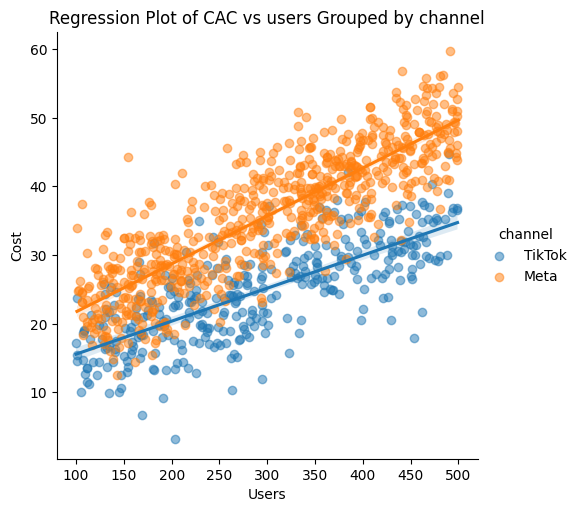

In [27]:
# Hay otras maneras de poner esta gráfica esta es la mas rapida
sns.lmplot(
    data=df_mark,
    x="users",
    y="cost",
    hue="channel",
    scatter_kws={"alpha": 0.5}
)
plt.title(f"Regression Plot of CAC vs users Grouped by channel")
plt.xlabel("Users")
plt.ylabel("Cost")
plt.show()

### Optimización de presupuesto

In [28]:
from scipy.optimize import minimize

budget = 15000

# Función de usuarios totales a maximizar
def total_users(x):
    titok_users, meta_users = x
    return -1 * (titok_users + meta_users)  # Negativo para maximizar con minimize

# Función de costo total, sujeto a la restricción del presupuesto
def total_cost(x):
    titok_users, meta_users = x
    return (titok_users * cac_tiktok_ads(titok_users) +
            meta_users * cac_meta_ads(meta_users)
    )
# Restricciones
constraints = [
    {'type': 'ineq', 'fun': lambda x: budget - total_cost(x)}  # Restricción de presupuesto
]

# Límite inferior para cada variable (no se pueden adquirir usuarios negativos)
bounds = [(0, None), (0, None)]

# Suposición inicial
initial_guess = [100, 100]

# Resolver el problema de optimización
result = minimize(total_users, initial_guess, constraints=constraints, bounds=bounds)

# Mostrar resultados
print("Usuarios adquiridos por  cada canal:")
print(f"Tik Tok usuarios: {int(result.x[0])}")
print(f"Meta usuarios: {int(result.x[1])}")

print(f"Costo total estimado: ${total_cost(result.x):,.2f}")
print(f"Usuarios totales adquiridos: {int(-result.fun)}")

print(f"Costo TikTok: ${round(int(result.x[0]) * cac_tiktok_ads(int(result.x[0])))}")
print(f"Costo Meta: ${round(int(result.x[1]) * cac_meta_ads(int(result.x[1])))}")

Usuarios adquiridos por  cada canal:
Tik Tok usuarios: 337
Meta usuarios: 203
Costo total estimado: $15,000.00
Usuarios totales adquiridos: 541
Costo TikTok: $9083
Costo Meta: $5872


---

## Parte Extra (Opcional, 5 puntos): Integración de AI para mejorar la atención a clientes.

**Contexto**  
Correcaminos, SA de CV le solicito a AnalyticsPro Solutions que explore soluciones basadas en Inteligencia Artificial para dar un mejor servicio a clientes usando IA para mejorar su Churn y NPS. Esto dado que quieren escalar su operación sin embargo solo quieren hacerlo si mejora sus métricas.

**Ejercicio Opcional**
1. **Beneficios del Uso de AI e integración (5 puntos):** 
    - Que beneficios tendría usar la IA.
    - Haz una estrategia de como podrías implementar IA para mejorar la atención a clientes. ¿Cómo harías esta integración?, ¿usarías algún tipo de prueba?